In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 读取二进制文件
hanning_window_analy = np.fromfile('Anly_Windows.bin', dtype=np.float16)

# 绘制图形
plt.plot(hanning_window_analy)
plt.title("Anly_Windows Data")
plt.xlabel("Index")
plt.ylabel("Value")
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 读取二进制文件
hanning_window_Sys = np.fromfile('Sys_Windows.bin', dtype=np.float16)

# 绘制图形
plt.plot(hanning_window_Sys)
plt.title("Sys_Windows Data")
plt.xlabel("Index")
plt.ylabel("Value")
plt.show()

In [ ]:
# 初始化存储矩阵和叠加结果
frames_Num = 30
# 计算总时间长度
hop_length = 64
win_length = 256
hanning_window = hanning_window_analy*hanning_window_Sys
total_length = (frames_Num - 1) * hop_length + win_length



window_matrix = np.zeros((frames_Num, total_length))
sum_signal = np.zeros(total_length)

# 生成每个窗口
for i in range(frames_Num):
    start = i * hop_length
    end = start + win_length
    window_matrix[i, start:end] = hanning_window
    sum_signal[start:end] += hanning_window

# 创建画布
plt.figure(figsize=(10, 12))
# 绘制Analy
plt.subplot(4, 1, 1)
plt.plot(hanning_window_analy, 'r-', linewidth=2)
plt.title('Analy Windows')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
# 绘制sys
plt.subplot(4, 1, 2)
plt.plot(hanning_window_Sys, 'r-', linewidth=2)
plt.title('Sys Windows')
plt.xlabel('Samples')
plt.ylabel('Amplitude')

# 绘制所有窗口
plt.subplot(4, 1, 3)
for i in range(frames_Num):
    plt.plot(window_matrix[i], alpha=0.5, label=f'Window {i+1}' if i < 3 else "")
plt.title(f'{frames_Num} Hanning Windows (hop={hop_length}, win={win_length})')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.legend(loc='upper right')

# 绘制叠加结果
plt.subplot(4, 1, 4)
plt.plot(sum_signal, 'r-', linewidth=2)
plt.title('Sum of All Windows')
plt.xlabel('Samples')
plt.ylabel('Amplitude')

plt.tight_layout()
plt.show()

In [33]:
import numpy as np
from scipy.io import wavfile
import matplotlib.pyplot as plt
import librosa
def read_waveform_normalized(filename):
    # 读取WAV文件（返回int16数组）
    sample_rate, data = wavfile.read(filename)
    
    # 转换为float并归一化到[-1, 1]
    if data.dtype == np.int16:
        data_float = data.astype(np.float32) / 32768.0  # 注意用32768.0避免溢出
    else:
        raise ValueError("Unsupported WAV format")
    
    return sample_rate, data_float
def plot_waveform(filename):
    sample_rate, data = read_waveform_normalized(filename)
    time = np.arange(len(data)) / sample_rate
    
    plt.figure(figsize=(12, 4))
    plt.plot(time, data)
    plt.title(f"Waveform: {filename}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (Normalized)")
    plt.grid(True)
    plt.show()
def plot_time_frequency(filename):
    """绘制时频图（语谱图）"""
    # 读取音频（使用librosa保持采样率一致）
    sample_rate, data = wavfile.read(filename)
    data = data.astype(np.float32)
    
    # 处理立体声（取左声道）
    if len(data.shape) == 2:
        data = data[:, 0]
    
    # 短时傅里叶变换参数
    n_fft = 2048       # FFT窗口大小
    hop_length = 512   # 帧移
    win_length = 2048  # 窗口长度
    window = 'hann'    # 窗函数类型
    
    # 计算STFT
    stft = librosa.stft(data, n_fft=n_fft, hop_length=hop_length,
                        win_length=win_length, window=window)
    
    # 转换为分贝单位
    spectrogram = librosa.amplitude_to_db(np.abs(stft), ref=np.max)
    
    # 创建画布
    plt.figure(figsize=(14, 6))
    
    # 绘制时频图
    librosa.display.specshow(spectrogram, sr=sample_rate,
                            hop_length=hop_length,
                            x_axis='time', y_axis='linear',
                            cmap='magma')
    
    # 设置颜色条
    plt.colorbar(format='%+2.0f dB')
    plt.title(f'Time-Frequency Analysis: {filename}')
    plt.tight_layout()
    plt.show()



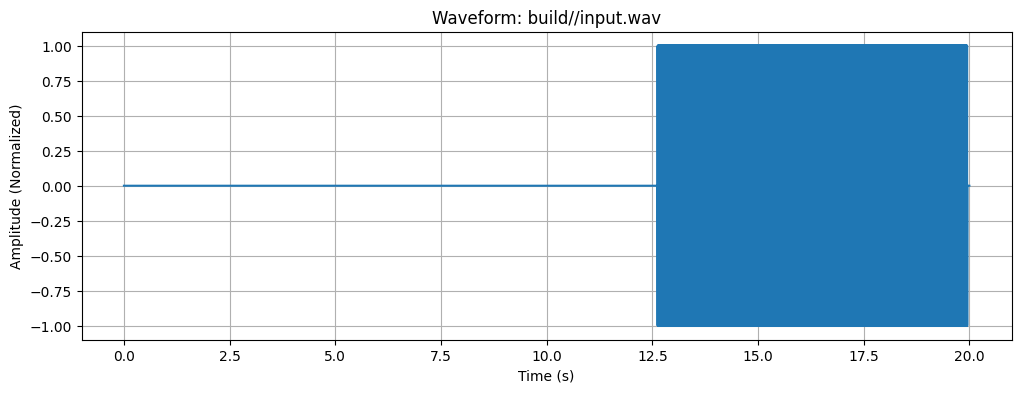

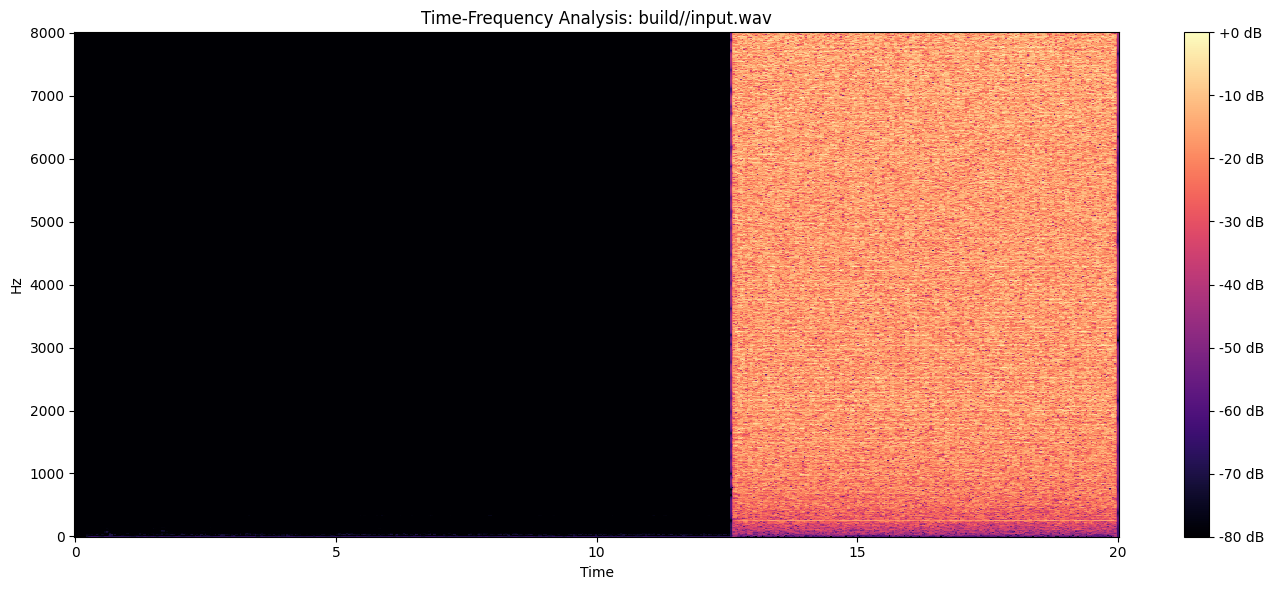

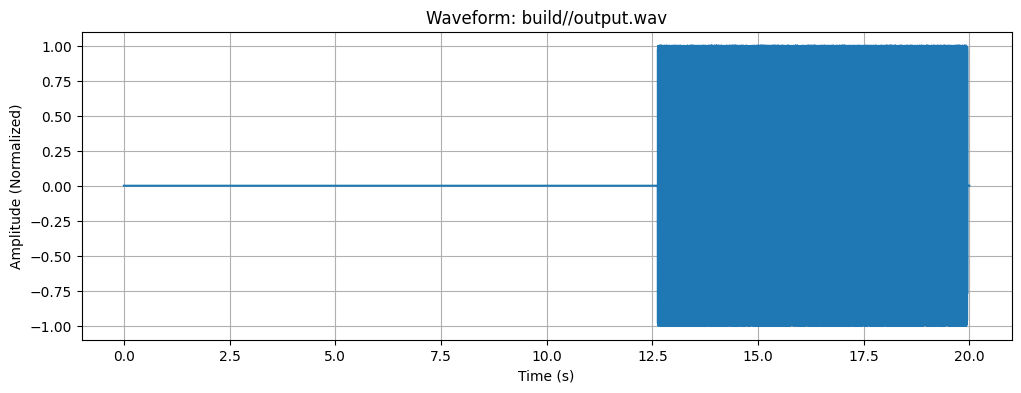

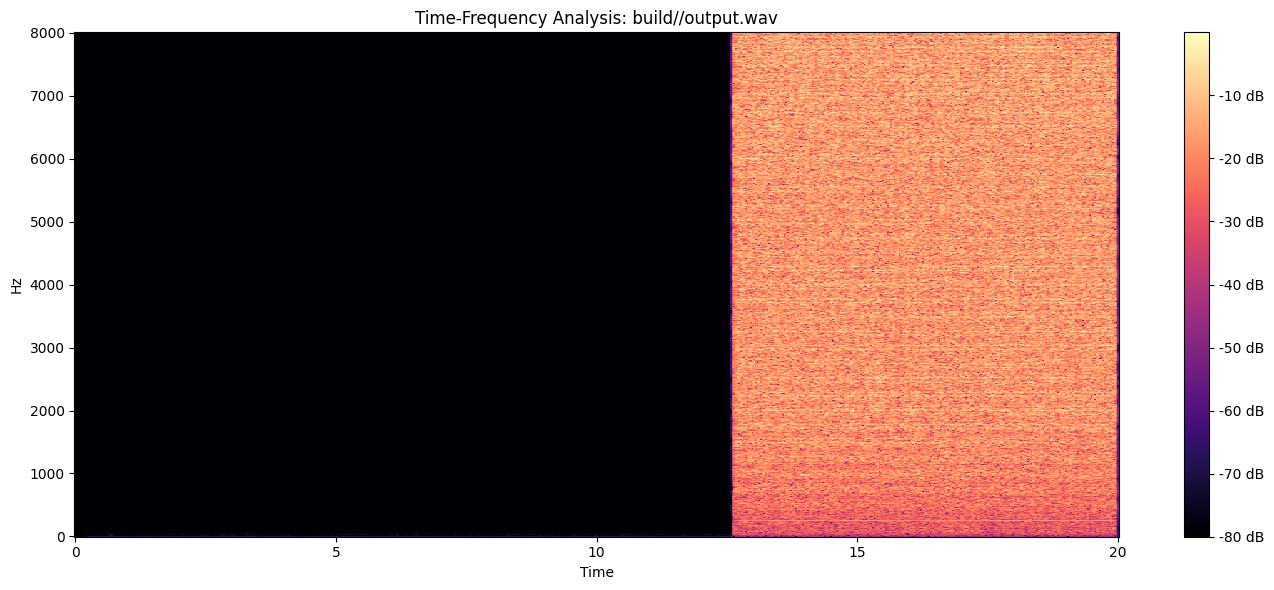

In [34]:
plot_waveform("build//input.wav")
plot_time_frequency("build//input.wav")
plot_waveform("build//output.wav")
plot_time_frequency("build//output.wav")